- raccolta dataset, standardizzazione e creazione finale di un merged df
- EDA, prime statistiche descrittive del df merged

In [ ]:
import pandas as pd
import numpy as np
import re
from google.colab import drive
drive.mount('/content/drive')
from functools import reduce
from sklearn.preprocessing import MinMaxScaler

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset

## 1. OECD - Current Well-Being

In [ ]:
wellbeingOECD = pd.read_csv('/content/drive/My Drive/DataScienceLab/OECD.wellbeing.csv')

In [ ]:
wellbeingOECD.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'MEASURE', 'Measure', 'UNIT_MEASURE',
       'Unit of measure', 'AGE', 'Age', 'SEX', 'Sex', 'EDUCATION_LEV',
       'Education level', 'DOMAIN', 'Domain', 'TIME_PERIOD', 'Time period',
       'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status',
       'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals', 'BASE_PER',
       'Base period'],
      dtype='object')

In [ ]:
wellbeingOECD = wellbeingOECD[['Reference area', 'Measure', 'TIME_PERIOD' , 'OBS_VALUE']]
wellbeingOECD

,Reference area,Measure,TIME_PERIOD,OBS_VALUE
0,Austria,Housing affordability,2021,78.931557
1,Belgium,Housing affordability,2022,79.644038
2,Czechia,Housing affordability,2020,74.056895
3,Denmark,Households and NPISHs net adjusted disposable ...,2023,40742.000000
4,Estonia,Housing affordability,2020,80.905290
...,...,...,...,...
1172,Romania,Social support,2022,83.512943
1173,Romania,Social support,2021,83.512943
1174,Romania,Social support,2020,83.512943
1175,Romania,Social support,2019,81.499271


In [ ]:
# Standardizzo nome colonne
wellbeingOECD = wellbeingOECD.rename(columns={
    'Reference area': 'Country',
    'Measure': 'Measure',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Value'
})

In [ ]:
# measure -> colonne, value -> celle
df_cb = (
    wellbeingOECD.pivot_table(
        index=["Country", "Year"],
        columns="Measure",
        values="Value",
        aggfunc="mean"   # in caso ci sono duplicati, facciamo media (non dovrebbero esserci)
    )
    .reset_index()
)

In [ ]:
df_cb

Measure,Country,Year,Employment rate,Exposed to air pollution,Households and NPISHs net adjusted disposable income per capita,Housing affordability,Job satisfaction,Lack of social support,Life expectancy at birth,Life satisfaction,Satisfaction with personal relationships,Social support
0,Austria,2019,77.654,99.986336,46162.0,79.202961,NaN,7.208514,82.0,NaN,NaN,92.101824
1,Austria,2020,76.457,99.986313,45404.0,78.738769,NaN,11.183687,81.3,NaN,NaN,88.693065
2,Austria,2021,76.428,NaN,47037.0,78.931557,NaN,11.183687,81.3,7.991946,NaN,88.693065
3,Austria,2022,78.006,NaN,47149.0,79.227486,NaN,11.183687,81.4,7.882644,8.563455,88.693065
4,Austria,2023,77.920,NaN,46610.0,79.343975,7.713388,10.311644,81.9,7.696147,NaN,89.688356
...,...,...,...,...,...,...,...,...,...,...,...,...
169,United Kingdom,2020,79.642,99.126610,40112.0,76.134329,NaN,11.759789,80.3,7.390000,NaN,88.072618
170,United Kingdom,2021,79.348,NaN,41845.0,76.162720,NaN,11.759789,80.5,7.540000,NaN,88.072618
171,United Kingdom,2022,79.786,NaN,40701.0,75.760236,NaN,11.759789,80.9,7.450000,NaN,88.072618
172,United Kingdom,2023,80.004,NaN,41002.0,76.471179,NaN,11.145393,81.0,NaN,NaN,88.761047


In [ ]:
df_cb = df_cb.drop(columns=['Lack of social support'])
display(df_cb.head())

Measure,Country,Year,Employment rate,Exposed to air pollution,Households and NPISHs net adjusted disposable income per capita,Housing affordability,Job satisfaction,Life expectancy at birth,Life satisfaction,Satisfaction with personal relationships,Social support
0,Austria,2019,77.654,99.986336,46162.0,79.202961,NaN,82.0,NaN,NaN,92.101824
1,Austria,2020,76.457,99.986313,45404.0,78.738769,NaN,81.3,NaN,NaN,88.693065
2,Austria,2021,76.428,NaN,47037.0,78.931557,NaN,81.3,7.991946,NaN,88.693065
3,Austria,2022,78.006,NaN,47149.0,79.227486,NaN,81.4,7.882644,8.563455,88.693065
4,Austria,2023,77.920,NaN,46610.0,79.343975,7.713388,81.9,7.696147,NaN,89.688356


## 2. OECD - safety

In [ ]:
safetyOECD = pd.read_csv('/content/drive/My Drive/DataScienceLab/OECD.safety.csv')

In [ ]:
safetyOECD = safetyOECD[['Reference area', 'Measure', 'TIME_PERIOD' , 'OBS_VALUE']]
safetyOECD

,Reference area,Measure,TIME_PERIOD,OBS_VALUE
0,Czechia,Feeling safe at night,2021,77.666667
1,Belgium,Feeling safe at night,2023,71.000000
2,Belgium,Feeling safe at night,2024,71.000000
3,Switzerland,Feeling safe at night,2023,87.500000
4,Greece,Feeling safe at night,2022,66.333333
...,...,...,...,...
186,Denmark,Feeling safe at night,2021,86.333333
187,Czechia,Feeling safe at night,2018,72.500000
188,Czechia,Feeling safe at night,2023,75.500000
189,Czechia,Feeling safe at night,2024,75.500000


In [ ]:
# Standardizzo nome colonne
safetyOECD = safetyOECD.rename(columns={
    'Reference area': 'Country',
    'Measure': 'Measure',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Value'
})

In [ ]:
df_saf = (
    safetyOECD.pivot_table(
        index=["Country", "Year"],
        columns="Measure",
        values="Value",
        aggfunc="mean"   # in caso ci sono duplicati, facciamo media (non dovrebbero esserci)
    )
    .reset_index()
)

In [ ]:
df_saf

Measure,Country,Year,Feeling safe at night
0,Austria,2018,84.000000
1,Austria,2019,84.000000
2,Austria,2020,82.333333
3,Austria,2021,82.333333
4,Austria,2022,82.333333
...,...,...,...
186,United Kingdom,2020,73.666667
187,United Kingdom,2021,73.666667
188,United Kingdom,2022,73.666667
189,United Kingdom,2023,76.000000


## 3. WordBank

In [ ]:
wb = pd.read_csv('/content/drive/My Drive/DataScienceLab/WB.econfeat.csv')

In [ ]:
wb=wb[['Country Name', 'Time', 'GDP per capita, PPP (current international $) [NY.GDP.PCAP.PP.CD]', 'Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]',
         'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]', 'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter) [EN.ATM.PM25.MC.M3]',
         'Intentional homicides (per 100,000 people) [VC.IHR.PSRC.P5]', 'Households and NPISHs Final consumption expenditure, PPP (current international $) [NE.CON.PRVT.PP.CD]']]
wb = wb.rename(columns={
    'GDP per capita, PPP (current international $) [NY.GDP.PCAP.PP.CD]': 'GDP_per_capita_PPP',
    'Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]': 'Unemployment_total_percent',
    'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]': 'Life_expectancy',
    'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter) [EN.ATM.PM25.MC.M3]': 'PM2_5_air_pollution',
    'Intentional homicides (per 100,000 people) [VC.IHR.PSRC.P5]': 'Intentional_homicides',
    'Households and NPISHs Final consumption expenditure, PPP (current international $) [NE.CON.PRVT.PP.CD]': 'Household_consumption_expenditure_PPP'
})

In [ ]:
# Remove the last 5 rows from the DataFrame
wb = wb.iloc[:-5]

In [ ]:
wb

,Country Name,Time,GDP_per_capita_PPP,Unemployment_total_percent,Life_expectancy,PM2_5_air_pollution,Intentional_homicides,Household_consumption_expenditure_PPP
0,Albania,2018.0,15054.9984743848,12.304,79.238,19.0461862321065,2.28039848927055,23497531697.8471
1,Albania,2019.0,16441.8041908551,11.466,79.467,15.70470712234,2.25302550996799,25353808485.5976
2,Albania,2020.0,16287.6432648867,11.69,77.824,15.7070036417042,2.12398982086583,23913980458.792
3,Albania,2021.0,18212.8532699363,11.474,76.844,..,2.31608568885389,25618152056.6915
4,Albania,2022.0,22032.4608490664,10.137,78.769,..,1.6975478920699,31167734728.7449
...,...,...,...,...,...,...,...,...
268,Ukraine,2020.0,15541.02734375,9.475,73.283,14.90010098879,3.80035686872931,398807765131.014
269,Ukraine,2021.0,17846.408203125,9.834,71.631,..,3.77663964401616,434872553801.325
270,Ukraine,2022.0,14770.0712890625,..,72.658,..,..,350860916693.286
271,Ukraine,2023.0,17665.34375,..,73.422,..,..,386849762789.955


In [ ]:
# Standardizzo nome colonne
df_wb = wb.rename(columns={
    'Country Name': 'Country',
    'Time': 'Year',
    'GDP_per_capita_PPP': 'GDP per capita PPP',
    'Unemployment_total_percent': 'Unemployment total percent',
    'Life_expectancy':'Life expectancy',
    'PM2_5_air_pollution': 'PM2.5 air pollution',
    'Intentional_homicides': 'Intentional homicides',
    'Household_consumption_expenditure_PPP': 'Household consumption expenditure PPP'
})

In [ ]:
df_wb.replace("..", np.nan, inplace=True)

In [ ]:
df_wb

,Country,Year,GDP per capita PPP,Unemployment total percent,Life expectancy,PM2.5 air pollution,Intentional homicides,Household consumption expenditure PPP
0,Albania,2018.0,15054.9984743848,12.304,79.238,19.0461862321065,2.28039848927055,23497531697.8471
1,Albania,2019.0,16441.8041908551,11.466,79.467,15.70470712234,2.25302550996799,25353808485.5976
2,Albania,2020.0,16287.6432648867,11.69,77.824,15.7070036417042,2.12398982086583,23913980458.792
3,Albania,2021.0,18212.8532699363,11.474,76.844,NaN,2.31608568885389,25618152056.6915
4,Albania,2022.0,22032.4608490664,10.137,78.769,NaN,1.6975478920699,31167734728.7449
...,...,...,...,...,...,...,...,...
268,Ukraine,2020.0,15541.02734375,9.475,73.283,14.90010098879,3.80035686872931,398807765131.014
269,Ukraine,2021.0,17846.408203125,9.834,71.631,NaN,3.77663964401616,434872553801.325
270,Ukraine,2022.0,14770.0712890625,NaN,72.658,NaN,NaN,350860916693.286
271,Ukraine,2023.0,17665.34375,NaN,73.422,NaN,NaN,386849762789.955


In [ ]:
df_wb['Year']=df_wb['Year'].astype(int)

## 4. NUMBEO - Cost of living

In [ ]:
df_cost = pd.read_excel('/content/drive/My Drive/DataScienceLab/NUMBEO.CostOfLiving.xlsx')

In [ ]:
df_cost

,Country,Year,Cost of living Index,Rent Index
0,Albania,2024,40.8,10.2
1,Albania,2023,37.4,9.1
2,Albania,2022,35.5,8.5
3,Albania,2021,40.2,9.2
4,Albania,2020,36.4,8.5
...,...,...,...,...
296,United Kingdom,2022,69.7,31.8
297,United Kingdom,2021,71.0,31.6
298,United Kingdom,2020,67.3,29.8
299,United Kingdom,2019,65.3,28.6


## 5. NUMBEO - Mobility

In [ ]:
df_mob = pd.read_excel('/content/drive/My Drive/DataScienceLab/NUMBEO.mobility.xlsx')

In [ ]:
df_mob

,Country,Year,Traffic Index,Time Index,Inefficiency Index,CO2 Emission Index
0,Albania,2024,114.7,36.7,105.7,1492.0
1,Albania,2023,NaN,NaN,NaN,NaN
2,Albania,2022,NaN,NaN,NaN,NaN
3,Albania,2021,NaN,NaN,NaN,NaN
4,Albania,2020,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
254,United Kingdom,2022,132.6,34.4,158.3,4076.0
255,United Kingdom,2021,132.7,34.4,158.9,4060.2
256,United Kingdom,2020,133.9,34.5,162.6,4144.5
257,United Kingdom,2019,133.3,34.6,161.4,4025.6


In [ ]:
# Pulizia specifica del nome colonna (rimozione del carattere invisibile \xa0)
# Usiamo una regex per catturare qualsiasi tipo di spazio tra 'CO2' e 'Emission'
df_mob.columns = [re.sub(r'CO2\s+Emission', 'CO2 Emission', col) for col in df_mob.columns]

# Alternativa esplicita se preferisci il rename diretto:
# df_mob = df_mob.rename(columns={'CO2\xa0Emission Index': 'CO2 Emission Index'})

display(df_mob.head())

,Country,Year,Traffic Index,Time Index,Inefficiency Index,CO2 Emission Index
0,Albania,2024,114.7,36.7,105.7,1492.0
1,Albania,2023,NaN,NaN,NaN,NaN
2,Albania,2022,NaN,NaN,NaN,NaN
3,Albania,2021,NaN,NaN,NaN,NaN
4,Albania,2020,NaN,NaN,NaN,NaN


## Standardizzo nomi nazioni

In [ ]:
COUNTRY_MAP = {
    # Czech / Slovakia
    "Czech Republic": "Czechia",
    "Slovak Republic": "Slovakia",

    # Bosnia
    "Bosnia And Herzegovina": "Bosnia and Herzegovina",

    # UK
    "UK": "United Kingdom",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
}

In [ ]:
def standardize_countries(df, col="country"):
    df = df.copy()
    df[col] = (
        df[col].astype(str)
              .str.strip()
              .replace(COUNTRY_MAP)
    )
    return df

In [ ]:
df_cb = standardize_countries(df_cb, col="Country")
df_saf = standardize_countries(df_saf, col="Country")
df_wb = standardize_countries(df_wb, col="Country")
df_cost = standardize_countries(df_cost, col="Country")
df_mob = standardize_countries(df_mob, col="Country")

## Merge finale

In [ ]:
dfs = [
    df_cb,     # current well-being
    df_saf,    # safety
    df_wb,     # economy
    df_cost,   # cost of living
    df_mob     # mobility
]

In [ ]:
df_merged = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=["Country", "Year"],
        how="outer"
    ),
    dfs
)

In [ ]:
df_merged

,Country,Year,Employment rate,Exposed to air pollution,Households and NPISHs net adjusted disposable income per capita,Housing affordability,Job satisfaction,Life expectancy at birth,Life satisfaction,Satisfaction with personal relationships,...,Life expectancy,PM2.5 air pollution,Intentional homicides,Household consumption expenditure PPP,Cost of living Index,Rent Index,Traffic Index,Time Index,Inefficiency Index,CO2 Emission Index
0,Albania,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,79.238,19.0461862321065,2.28039848927055,23497531697.8471,37.9,7.3,NaN,NaN,NaN,NaN
1,Albania,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,79.467,15.70470712234,2.25302550996799,25353808485.5976,36.2,8.2,NaN,NaN,NaN,NaN
2,Albania,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.824,15.7070036417042,2.12398982086583,23913980458.792,36.4,8.5,NaN,NaN,NaN,NaN
3,Albania,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.844,NaN,2.31608568885389,25618152056.6915,40.2,9.2,NaN,NaN,NaN,NaN
4,Albania,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,78.769,NaN,1.6975478920699,31167734728.7449,35.5,8.5,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,United Kingdom,2020,79.642,99.12661,40112.0,76.134329,NaN,80.3,7.39,NaN,...,80.331756097561,9.91288560282114,0.94577935310667,1658606612474.49,67.3,29.8,133.9,34.5,162.6,4144.5
332,United Kingdom,2021,79.348,NaN,41845.0,76.162720,NaN,80.5,7.54,NaN,...,80.6473170731707,NaN,1.11868407522333,1861682009198.74,71.0,31.6,132.7,34.4,158.9,4060.2
333,United Kingdom,2022,79.786,NaN,40701.0,75.760236,NaN,80.9,7.45,NaN,...,81.0112195121951,NaN,NaN,2214067915948.42,69.7,31.8,132.6,34.4,158.3,4076.0
334,United Kingdom,2023,80.004,NaN,41002.0,76.471179,NaN,81.0,NaN,NaN,...,81.2380975609756,NaN,NaN,2337820437950.04,61.5,30.3,133.8,34.6,160.9,4081.1


In [ ]:
sorted(df_merged["Country"].unique())

['Albania',
 'Andorra',
 'Austria',
 'Azerbaijan',
 'Belarus',
 'Belgium',
 'Bosnia and Herzegovina',
 'Bulgaria',
 'Croatia',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Guernsey',
 'Hungary',
 'Iceland',
 'Ireland',
 'Isle Of Man',
 'Italy',
 'Jersey',
 'Kosovo (Disputed Territory)',
 'Latvia',
 'Liechtenstein',
 'Lithuania',
 'Luxembourg',
 'Malta',
 'Moldova',
 'Monaco',
 'Montenegro',
 'Netherlands',
 'North Macedonia',
 'Norway',
 'Poland',
 'Portugal',
 'Romania',
 'Russia',
 'San Marino',
 'Serbia',
 'Slovakia',
 'Slovenia',
 'Spain',
 'Sweden',
 'Switzerland',
 'Ukraine',
 'United Kingdom']

In [ ]:
sorted(df_merged["Year"].unique())


[np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024)]

In [ ]:
# Export
path = "/content/drive/MyDrive/DataScienceLab/merged_data.csv"
df_merged.to_csv(path, index=False)

### Data Integration Workflow

In [ ]:
import graphviz

# Crea il diagramma con orientamento dall'alto verso il basso (Top-Bottom)
dot = graphviz.Digraph(comment='Career Compass Data Pipeline')
dot.attr(rankdir='TB', size='10,8', nodesep='0.5', ranksep='0.8')

# Definizione stili
dot.attr('node', fontname='Arial', fontsize='11')

# Nodi Sorgenti Originali (Input)
with dot.subgraph(name='cluster_sources') as s:
    s.attr(label='Raw Data Sources', style='dashed', color='lightblue')
    s.node('raw_cb', 'OECD Well-being\n(CSV)', shape='note')
    s.node('raw_saf', 'OECD Safety\n(CSV)', shape='note')
    s.node('raw_wb', 'World Bank WDI\n(CSV)', shape='note')
    s.node('raw_num', 'Numbeo indices\n(Excel)', shape='note')

# Nodi Preprocessing Specifico
dot.node('pre_oecd', 'Pivoting & Feature Selection\n(df_cb, df_saf)', shape='component', color='darkgreen')
dot.node('pre_wb', 'Metadata Removal & NaN Handling\n(df_wb)', shape='component', color='darkgreen')
dot.node('pre_num', 'NYC Baseline Alignment\n(df_cost, df_mob)', shape='component', color='darkgreen')

# Nodo Armonizzazione (Il filtro comune)
dot.node('map', 'COUNTRY_MAP\nGeographical Standardization', shape='box3d', style='filled', color='darkgreen', fillcolor='lightgreen')

# Nodo Final Merge
dot.node('merge', 'Iterative\nOUTER JOIN', shape='invhouse', style='filled', color='darkgreen', fontcolor='white')

# Nodo Output Finale
dot.node('final', 'Unified Master Dataset\n(22 Indicators, 48 Countries, 7 Years)', shape='cylinder', style='filled', color='lightblue')

# Collegamenti (Flow)
dot.edge('raw_cb', 'pre_oecd')
dot.edge('raw_saf', 'pre_oecd')
dot.edge('raw_wb', 'pre_wb')
dot.edge('raw_num', 'pre_num')

dot.edge('pre_oecd', 'map')
dot.edge('pre_wb', 'map')
dot.edge('pre_num', 'map')

dot.edge('map', 'merge')
dot.edge('merge', 'final')

# Rendering
dot.render('data_integration_workflow', format='png', cleanup=True)

'data_integration_workflow.png'

### Statistiche descrittive

1. Analisi della Disparità Economica (Boxplot Comparativo)

Per comprendere la geografia economica del dataset, abbiamo proceduto all'identificazione dei paesi 'benchmark' che definiscono i limiti superiori e inferiori delle nostre dimensioni chiave: Benessere, Ricchezza e Costo della Vita. Questa analisi tabellare è propedeutica alla visualizzazione grafica, in quanto fornisce i valori esatti necessari per calibrare correttamente le scale e le legende del successivo modello di raccomandazione.

In [ ]:
# 1. Filtriamo l'ultimo anno disponibile (2024) per coerenza con le analisi correnti
latest_data = df_merged[df_merged['Year'] == df_merged['Year'].max()]

def get_top_bottom(df, column_name, ascending=False):
    """
    Estrae i primi 5 record per una colonna specifica.
    ascending=False -> Top 5 (Valori più alti)
    ascending=True  -> Bottom 5 (Valori più bassi)
    """
    # Rimuoviamo i NaN
    temp_df = df[['Country', column_name]].dropna()
    return temp_df.sort_values(by=column_name, ascending=ascending).head(5)

# --- ESECUZIONE RANKING COMPLETI ---

# A. Benessere (Life Satisfaction)
top_life = get_top_bottom(latest_data, 'Life satisfaction', ascending=False)
bottom_life = get_top_bottom(latest_data, 'Life satisfaction', ascending=True)

# B. Ricchezza (GDP per capita PPP)
top_gdp = get_top_bottom(latest_data, 'GDP per capita PPP', ascending=False)
bottom_gdp = get_top_bottom(latest_data, 'GDP per capita PPP', ascending=True)

# C. Costo della Vita (Cost of living Index)
# Nota: 'Affordable' significa indice basso, 'Expensive' significa indice alto
top_affordable = get_top_bottom(latest_data, 'Cost of living Index', ascending=True)
top_expensive = get_top_bottom(latest_data, 'Cost of living Index', ascending=False)

# --- STAMPA RISULTATI (Storytelling e Validazione) ---
print(f"--- RANKING: LIFE SATISFACTION (Target: {latest_data['Year'].max()}) ---")
print("TOP 5 (Most Satisfied):\n", top_life.to_string(index=False))
print("\nBOTTOM 5 (Least Satisfied):\n", bottom_life.to_string(index=False))

print(f"\n--- RANKING: WEALTH (GDP per capita PPP) ---")
print("TOP 5 (Wealthiest):\n", top_gdp.to_string(index=False))
print("\nBOTTOM 5 (Poorest):\n", bottom_gdp.to_string(index=False))

print(f"\n--- RANKING: COST OF LIVING ---")
print("TOP 5 AFFORDABLE (Cheapest):\n", top_affordable.to_string(index=False))
print("\nTOP 5 EXPENSIVE (Costliest):\n", top_expensive.to_string(index=False))

--- RANKING: LIFE SATISFACTION (Target: 2024) ---
TOP 5 (Most Satisfied):
     Country  Life satisfaction
    Finland           7.820319
    Romania           7.726957
   Slovenia           7.674131
    Austria           7.622019
Netherlands           7.618394

BOTTOM 5 (Least Satisfied):
  Country  Life satisfaction
Bulgaria           6.238715
  Greece           6.737667
  Latvia           6.932122
 Germany           6.983058
 Estonia           7.065762

--- RANKING: WEALTH (GDP per capita PPP) ---
TOP 5 (Wealthiest):
     Country GDP per capita PPP
Switzerland   94115.8242622014
Netherlands   84221.9783775078
    Iceland    81924.411472168
    Denmark   79514.2854383058
    Andorra   74939.4746038578

BOTTOM 5 (Poorest):
                Country GDP per capita PPP
                Norway   101031.460599068
            Luxembourg   150929.364202573
               Ukraine    18550.462890625
Bosnia and Herzegovina   22955.7616198884
            Azerbaijan   25088.9993757134

--- RANKING: 

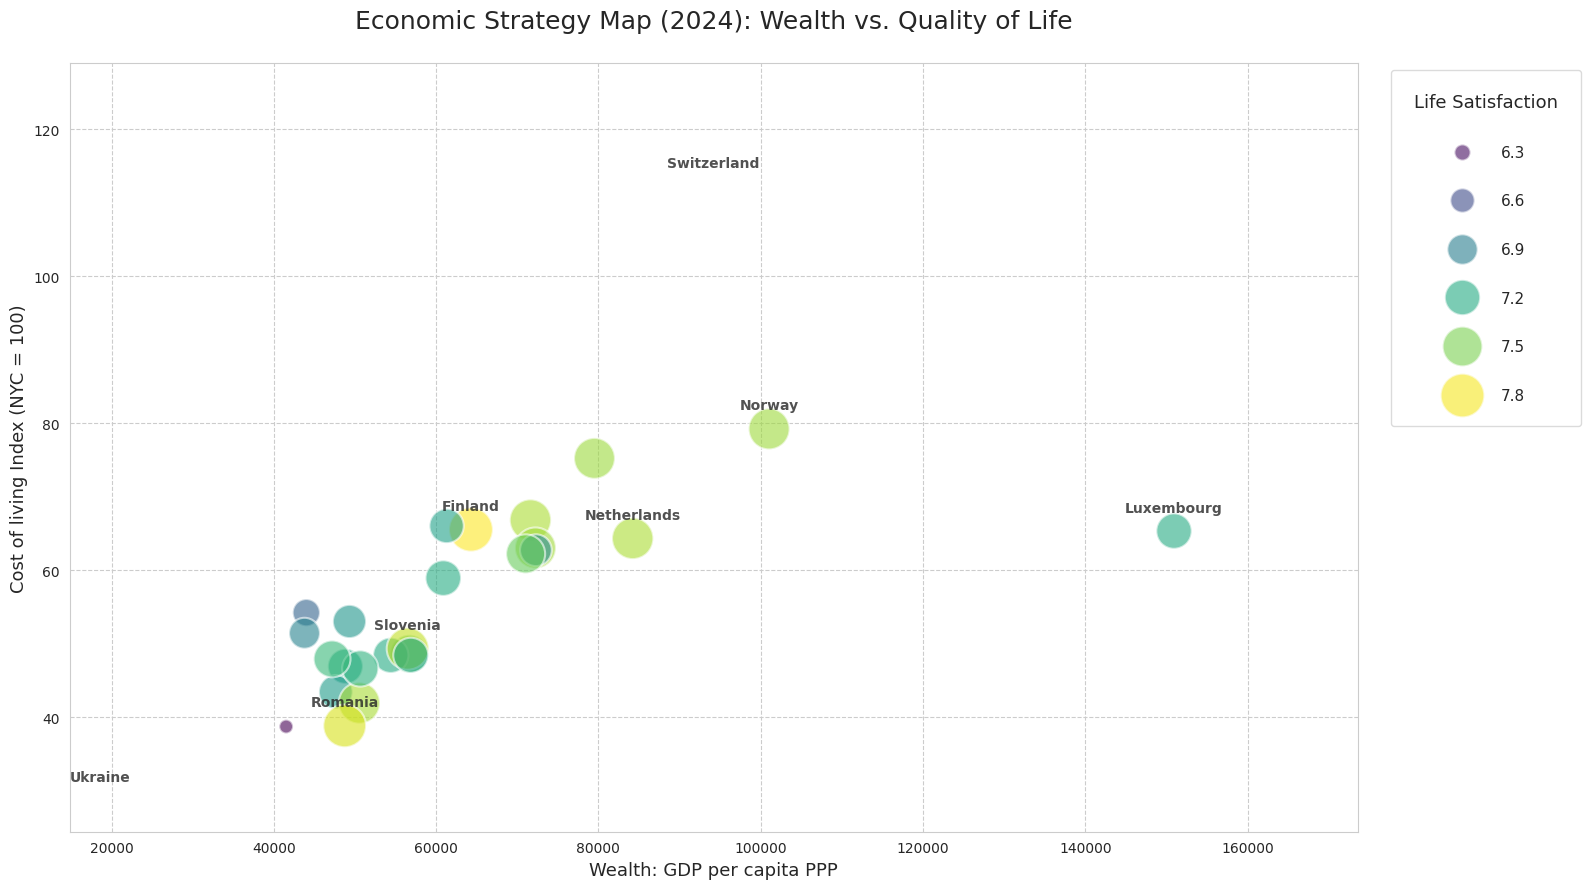

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparazione dei dati (Ultimo anno disponibile)
latest_year = df_merged['Year'].max()
df_latest = df_merged[df_merged['Year'] == latest_year].copy()

# Definizione nomi colonne
x_col = 'GDP per capita PPP'
y_col = 'Cost of living Index'
size_col = 'Life satisfaction'

# Converti in numerico: i testi non validi diventano NaN, ma la riga RESTA
for col in [x_col, y_col, size_col]:
    df_latest[col] = pd.to_numeric(df_latest[col], errors='coerce')

# 2. Configurazione dello stile del grafico
plt.figure(figsize=(16, 9))
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

# 3. Creazione dello Scatter Plot (Bubble Chart)
scatter = sns.scatterplot(
    data=df_latest,
    x=x_col,
    y=y_col,
    size=size_col,
    hue=size_col,
    sizes=(100, 1000), # Dimensione bolle nel grafico
    palette='viridis',
    alpha=0.6,
    edgecolor="w",
    linewidth=1.5
)

# 4. GESTIONE MARGINI E OUTLIER (Fix per Svizzera/Ucraina)
# Espandiamo i limiti per far stare dentro i nomi degli outlier
x_min, x_max = np.nanmin(df_latest[x_col]), np.nanmax(df_latest[x_col])
y_min, y_max = np.nanmin(df_latest[y_col]), np.nanmax(df_latest[y_col])

plt.xlim(x_min * 0.80, x_max * 1.15)
plt.ylim(y_min * 0.90, y_max * 1.15)

# 5. ETICHETTATURA SELETTIVA DEI PAESI
# Soglie per identificare i paesi più significativi
top_gdp = df_latest[x_col].quantile(0.90)
top_sat = df_latest[size_col].quantile(0.90)
low_cost = df_latest[y_col].quantile(0.10)
special_interest = ['Switzerland', 'Ukraine', 'Luxembourg', 'Norway', 'Finland', 'Romania', 'Slovenia', 'Netherlands']

for i in range(df_latest.shape[0]):
    row = df_latest.iloc[i]
    country = row['Country']

    if (row[x_col] >= top_gdp or
        row[size_col] >= top_sat or
        row[y_col] <= low_cost or
        country in special_interest):

        plt.text(
            x=row[x_col],
            y=row[y_col] + (y_max * 0.02), # Spazio verticale tra bolla e testo
            s=country,
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='bottom',
            alpha=0.8
        )

# 6. CONFIGURAZIONE LEGENDA SPAZIOSA (Fix sovrapposizione)
h, l = scatter.get_legend_handles_labels()
plt.legend(
    h, l,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title="Life Satisfaction",
    title_fontsize='13',
    fontsize='11',
    labelspacing=2.2,    # Aumenta lo spazio verticale tra i cerchi nella legenda
    handletextpad=1.5,   # Spazio tra cerchio e numero
    borderpad=1.5,       # Margine interno della cornice legenda
    frameon=True,
    edgecolor='lightgrey'
)

# 7. Estetica finale e Salvataggio
plt.title(f"Economic Strategy Map ({latest_year}): Wealth vs. Quality of Life", fontsize=18, pad=25)
plt.xlabel("Wealth: GDP per capita PPP", fontsize=13)
plt.ylabel("Cost of living Index (NYC = 100)", fontsize=13)

plt.tight_layout()
plt.savefig('strategic_economic_map.png', dpi=300, bbox_inches='tight')
plt.show()

Abbiamo calibrato la legenda sulla variazione reale dei dati ($[6.3, 7.8]$) per massimizzare la discriminazione visiva tra i paesi. Utilizzare l'intera scala 0-10 avrebbe appiattito le differenze cromatiche, rendendo indistinguibili nazioni con livelli di benessere significativamente diversi tra loro.

2. Analisi della Stabilità dei dati

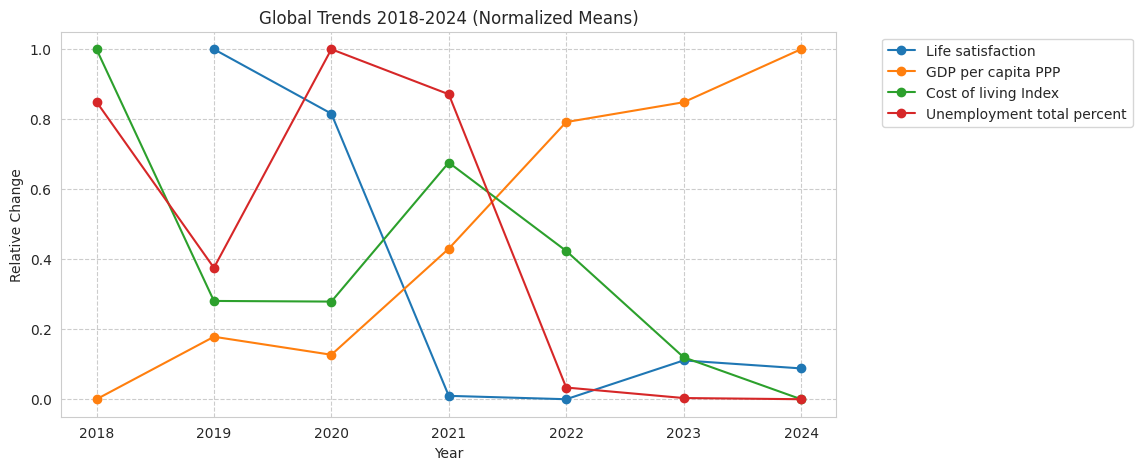

In [ ]:
# Andamento medio di alcuni indicatori chiave nel tempo
key_trends = [
    'Life satisfaction',          # Benessere (OECD)
    'GDP per capita PPP',         # Economia (World Bank)
    'Cost of living Index',       # Spesa (Numbeo)
    'Unemployment total percent'  # Lavoro (World Bank)
]

# Creiamo una copia per non sporcare il dataset originale
df_numeric = df_merged.copy()

# Convertiamo le colonne chiave in numeriche
for col in key_trends:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_trends = df_numeric.groupby('Year')[key_trends].mean()

# Normalizziamo solo per la visualizzazione (per vederli tutti insieme)
df_trends_norm = (df_trends - df_trends.min()) / (df_trends.max() - df_trends.min())

df_trends_norm.plot(figsize=(10, 5), marker='o')
plt.title("Global Trends 2018-2024 (Normalized Means)")
plt.ylabel("Relative Change")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('global_trends.png', dpi=300, bbox_inches='tight')
plt.show()

3. Missing Value Bar Chart

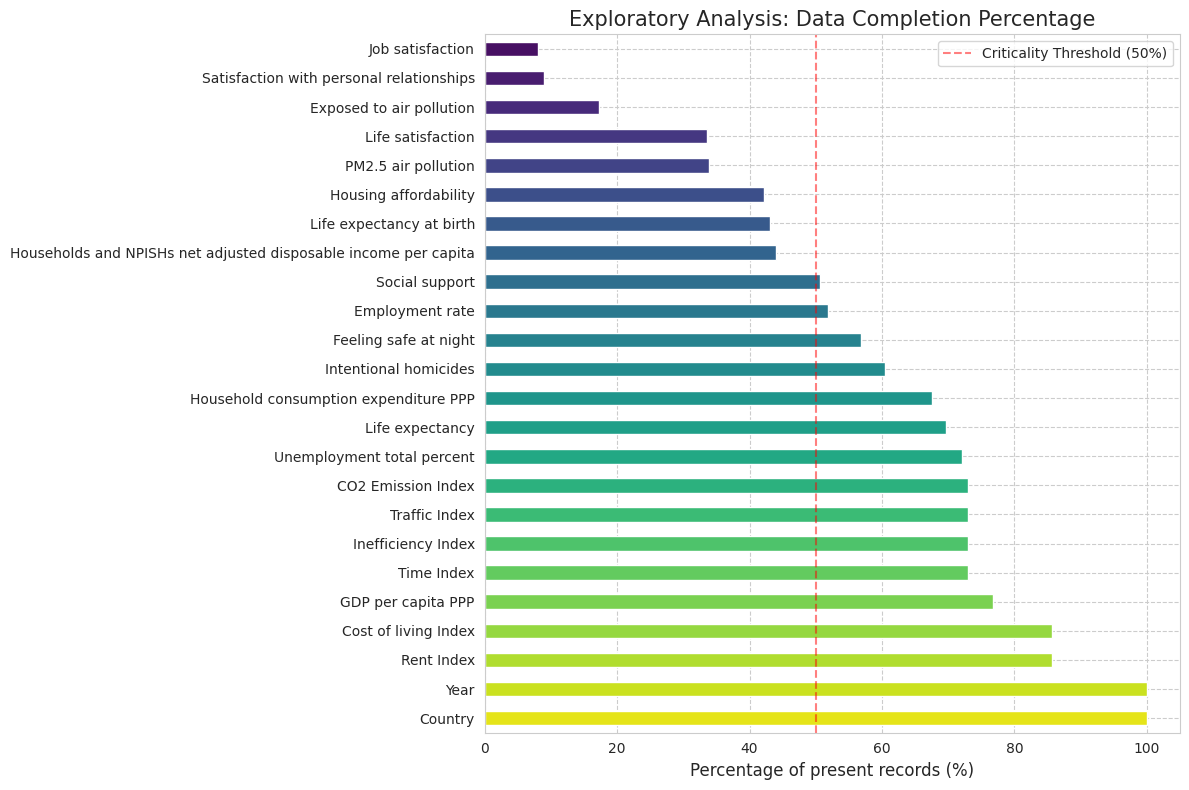

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculation of completion (inverse of missing values)
completion_pct = (1 - df_merged.isnull().mean()) * 100
completion_pct = completion_pct.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = sns.color_palette("viridis_r", len(completion_pct))
completion_pct.plot(kind='barh', color=colors)

# Titles and labels
plt.title("Exploratory Analysis: Data Completion Percentage", fontsize=15)
plt.xlabel("Percentage of present records (%)", fontsize=12)

# Criticality threshold update
plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Criticality Threshold (50%)')

plt.legend()
plt.tight_layout()

# Saving the updated figure
plt.savefig('completion_pct_chart.png', dpi=300, bbox_inches='tight')
plt.show()